In [2]:
#      NİŞANTAŞI ÜNİVERSİTESİ - YAPAY ZEKA UYGULAMALARI FİNAL PROJESİ
#      PROJE BAŞLIĞI : MANTAR ZEHİRLİLİK SINIFLANDIRMASI
#      HAZIRLAYAN : ENES SALTIK
#      ÖĞRENCİ NO : 20241011061
#      BÖLÜM : BİLGİSAYAR PROGRAMCILIĞI
#      VERİ SETİ : https://www.kaggle.com/datasets/uciml/mushroom-classification?resource=download

In [1]:
# Gerekli araçları (kütüphaneleri) çağırıyoruz
import pandas as pd
import numpy as np

# Veri setini bilgisayardan okuyoruz
df = pd.read_csv("mushrooms.csv")

# Tablonun ilk 5 satırını ekrana yazdırıyoruz
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [2]:
# 1. Veri setinin tam olarak kaç satır ve sütundan oluştuğunu görelim
print("Veri Seti Boyutu (Satır, Sütun):", df.shape)

# 2. Verideki kategorik harflerin genel bir istatistiksel özeti
print("\nİstatistiksel Özet:")
print(df.describe().T) # Daha rahat okunması için tersini (.T) alıyoruz

# 3. Gizli eksik verileri yakalama:
# Bu veri setinde eksik/bilinmeyen veriler '?' işareti ile girilmiştir.
# Bilgisayarın bunu "boş veri" olarak algılaması için '?' işaretlerini standart "NaN" formatına çeviriyoruz.
df.replace('?', np.nan, inplace=True)

# 4. Hangi sütunda kaç tane eksik (boş) veri var, net listesini çıkaralım
print("\nSütunlara Göre Eksik Veri Sayıları:")
print(df.isnull().sum())

Veri Seti Boyutu (Satır, Sütun): (8124, 23)

İstatistiksel Özet:
                         count unique top  freq
class                     8124      2   e  4208
cap-shape                 8124      6   x  3656
cap-surface               8124      4   y  3244
cap-color                 8124     10   n  2284
bruises                   8124      2   f  4748
odor                      8124      9   n  3528
gill-attachment           8124      2   f  7914
gill-spacing              8124      2   c  6812
gill-size                 8124      2   b  5612
gill-color                8124     12   b  1728
stalk-shape               8124      2   t  4608
stalk-root                8124      5   b  3776
stalk-surface-above-ring  8124      4   s  5176
stalk-surface-below-ring  8124      4   s  4936
stalk-color-above-ring    8124      9   w  4464
stalk-color-below-ring    8124      9   w  4384
veil-type                 8124      1   p  8124
veil-color                8124      4   w  7924
ring-number            

Verideki toplam eksik veri sayısı: 0


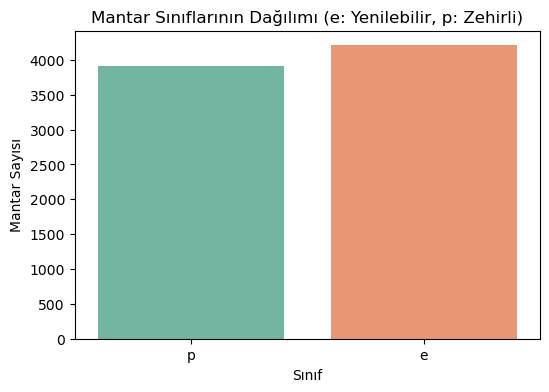

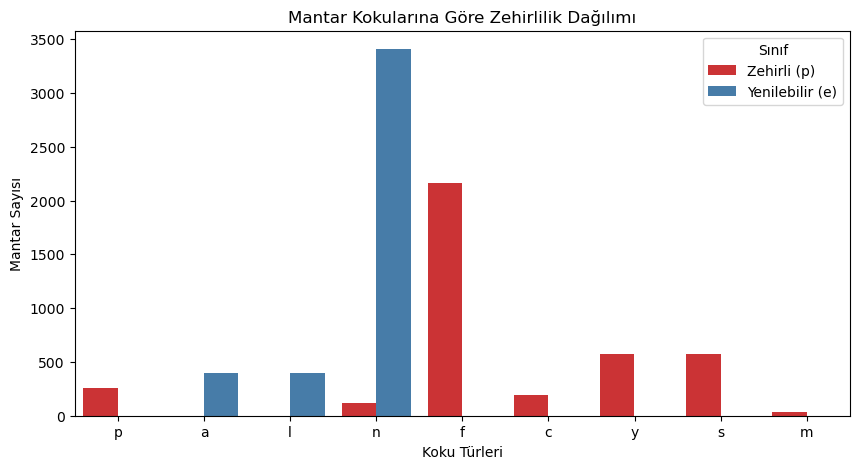

In [3]:
# 1. Eksik Verileri Doldurma (Imputation)
# stalk-root sütunundaki boş değerleri 'm' (missing) harfi ile dolduruyoruz
df['stalk-root'] = df['stalk-root'].fillna('m')

# Kontrol edelim, veri setinde hiç boş değer kaldı mı?
print("Verideki toplam eksik veri sayısı:", df.isnull().sum().sum())

# 2. VERİ GÖRSELLEŞTİRME
# Grafiklerin şık görünmesi için seaborn stilini ayarlıyoruz
import seaborn as sns
import matplotlib.pyplot as plt

# Grafik 1: Hedef Değişkenin Dağılımı (Mantar Sayıları)
plt.figure(figsize=(6,4))
sns.countplot(x='class', data=df, hue='class', palette='Set2', legend=False)
plt.title('Mantar Sınıflarının Dağılımı (e: Yenilebilir, p: Zehirli)')
plt.xlabel('Sınıf')
plt.ylabel('Mantar Sayısı')
plt.show()

# Grafik 2: Koku Özelliğine Göre Zehirlilik Durumu (En Belirgin Özellik)
plt.figure(figsize=(10,5))
sns.countplot(x='odor', hue='class', data=df, palette='Set1')
plt.title('Mantar Kokularına Göre Zehirlilik Dağılımı')
plt.xlabel('Koku Türleri')
plt.ylabel('Mantar Sayısı')
plt.legend(title='Sınıf', labels=['Zehirli (p)', 'Yenilebilir (e)'])
plt.show()

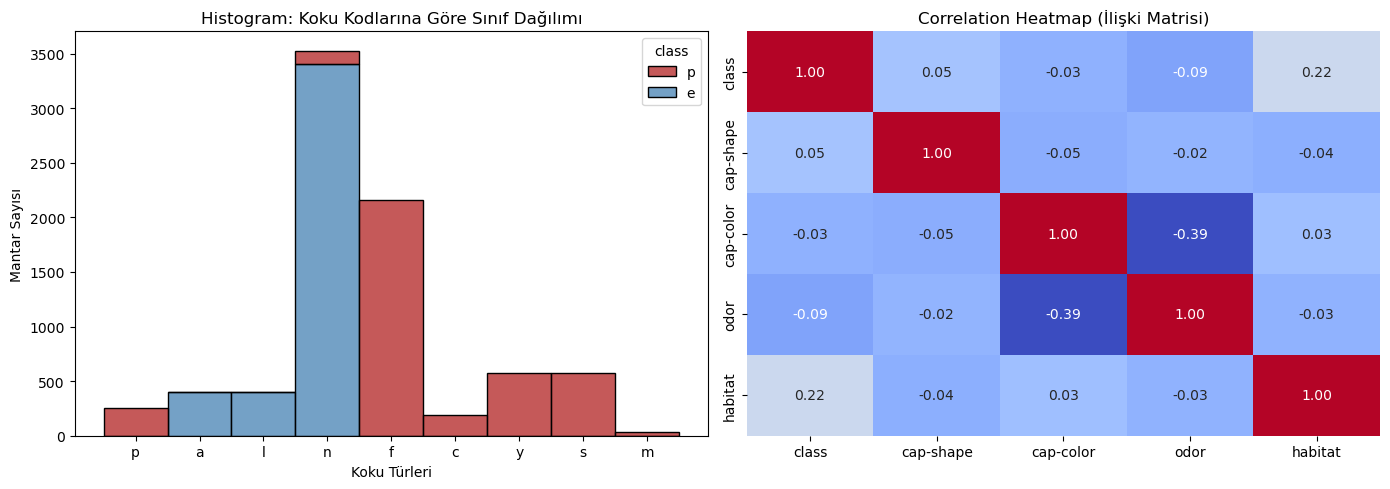

In [24]:
# ---  EK GÖRSELLEŞTİRMELER (EDA) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Yığılmış Histogram (Koku ve Sınıf Dağılımı)
sns.histplot(data=df, x='odor', hue='class', multiple='stack', 
             palette={'e': '#4682b4', 'p': '#b22222'}, ax=axes[0])
axes[0].set_title('Histogram: Koku Kodlarına Göre Sınıf Dağılımı')
axes[0].set_xlabel('Koku Türleri')
axes[0].set_ylabel('Mantar Sayısı')

# 2. Correlation Heatmap (Korelasyon Matrisi)
# Sadece sayısal verilere çevrilmiş df_encoded tablosunu kullanıyoruz
korelasyon_matrisi = df_encoded[['class', 'cap-shape', 'cap-color', 'odor', 'habitat']].corr()
sns.heatmap(korelasyon_matrisi, annot=True, fmt=".2f", cmap='coolwarm', cbar=False, ax=axes[1])
axes[1].set_title('Correlation Heatmap (İlişki Matrisi)')

plt.tight_layout()
plt.show()

In [4]:
# 3. KATEGORİK VERİLERİ SAYISAL DEĞERLERE ÇEVİRME (ENCODING)
# Python'un scikit-learn kütüphanesinden LabelEncoder aracını çağırıyoruz
from sklearn.preprocessing import LabelEncoder

# Veri setimizin bir kopyasını oluşturuyoruz (orijinali bozulmasın diye)
df_encoded = df.copy()
le = LabelEncoder()

# Döngü yardımıyla tablodaki 23 sütunun hepsini tek tek sayılara çeviriyoruz
for sutun in df_encoded.columns:
    df_encoded[sutun] = le.fit_transform(df_encoded[sutun])

# Bakalım harfler sayıya dönüşmüş mü? İlk 5 satırı kontrol edelim:
df_encoded.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,7,7,0,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,7,7,0,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,7,7,0,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,7,7,0,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,7,7,0,2,1,0,3,0,1


In [5]:
# 4. VERİYİ EĞİTİM VE TEST OLARAK AYIRMA (TRAIN-TEST SPLIT)
# Sklearn kütüphanesinden bölme aracını çağırıyoruz
from sklearn.model_selection import train_test_split

# Hedef değişkenimizi (class) ve bağımsız değişkenlerimizi (özellikleri) ayırıyoruz
# y = Tahmin etmek istediğimiz sütun (Sınıf: Zehirli mi / Yenilebilir mi)
# X = Geri kalan tüm fiziksel özellik sütunları (class dışındaki 22 sütun)
X = df_encoded.drop('class', axis=1)
y = df_encoded['class']

# Veriyi %80 Eğitim (Train) ve %20 Test olarak bölüyoruz
# random_state=42 veriyoruz ki kodu her çalıştırdığımızda aynı rastgelelikle bölünsün, sonuçlar değişmesin
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Bölme işleminin sonuçlarını ekrana yazdırıp kontrol edelim
print("Eğitim kümesindeki mantar sayısı (X_train):", X_train.shape[0])
print("Test kümesindeki mantar sayısı (X_test):", X_test.shape[0])

Eğitim kümesindeki mantar sayısı (X_train): 6499
Test kümesindeki mantar sayısı (X_test): 1625


--- 1. KOKUSUZ MODEL PERFORMANSI ---
Accuracy (Doğruluk): 0.8351
Precision (Kesinlik): 0.8482
Recall (Duyarlılık): 0.8005
F1-Score: 0.8237
ROC-AUC Skoru: 0.9176

--- 2. KOKULU MODEL PERFORMANSI ('odor' Eklendi) ---
Accuracy (Doğruluk): 0.9846
Precision (Kesinlik): 1.0000
Recall (Duyarlılık): 0.9680
F1-Score: 0.9838
ROC-AUC Skoru: 0.9966



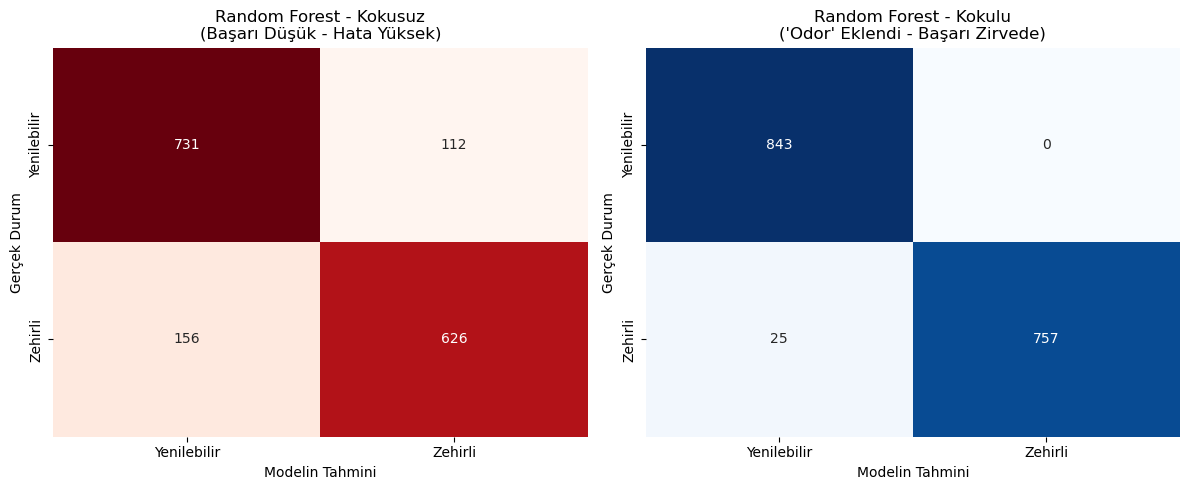

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# --- 1. ADIM: İKİ FARKLI ÖZELLİK SETİNİ HAZIRLAMA ---
kriterler_kokusuz = ['cap-shape', 'cap-color', 'stalk-shape', 'habitat'] # Koku YOK
kriterler_kokulu = ['cap-shape', 'cap-color', 'odor', 'habitat']         # Koku VAR

X_train_kokusuz = X_train[kriterler_kokusuz]
X_test_kokusuz = X_test[kriterler_kokusuz]

X_train_kokulu = X_train[kriterler_kokulu]
X_test_kokulu = X_test[kriterler_kokulu]

# --- 2. ADIM: RASTGELE ORMAN (RANDOM FOREST) EĞİTİMİ ---
rf_kokusuz = RandomForestClassifier(max_depth=5, min_samples_split=10, min_samples_leaf=5, random_state=42)
rf_kokulu = RandomForestClassifier(max_depth=5, min_samples_split=10, min_samples_leaf=5, random_state=42)

rf_kokusuz.fit(X_train_kokusuz, y_train)
rf_kokulu.fit(X_train_kokulu, y_train)

# --- 3. ADIM: TAHMİNLERİ VE OLASILIKLARI ALMA ---
rf_tahmin_kokusuz = rf_kokusuz.predict(X_test_kokusuz)
rf_olasilik_kokusuz = rf_kokusuz.predict_proba(X_test_kokusuz)[:, 1]

rf_tahmin_kokulu = rf_kokulu.predict(X_test_kokulu)
rf_olasilik_kokulu = rf_kokulu.predict_proba(X_test_kokulu)[:, 1]

# --- 4. ADIM: BAŞARI METRİKLERİNİN YAZDIRILMASI ---
print("--- 1. KOKUSUZ MODEL PERFORMANSI ---")
print(f"Accuracy (Doğruluk): {accuracy_score(y_test, rf_tahmin_kokusuz):.4f}")
print(f"Precision (Kesinlik): {precision_score(y_test, rf_tahmin_kokusuz):.4f}")
print(f"Recall (Duyarlılık): {recall_score(y_test, rf_tahmin_kokusuz):.4f}")
print(f"F1-Score: {f1_score(y_test, rf_tahmin_kokusuz):.4f}")
print(f"ROC-AUC Skoru: {roc_auc_score(y_test, rf_olasilik_kokusuz):.4f}\n")

print("--- 2. KOKULU MODEL PERFORMANSI ('odor' Eklendi) ---")
print(f"Accuracy (Doğruluk): {accuracy_score(y_test, rf_tahmin_kokulu):.4f}")
print(f"Precision (Kesinlik): {precision_score(y_test, rf_tahmin_kokulu):.4f}")
print(f"Recall (Duyarlılık): {recall_score(y_test, rf_tahmin_kokulu):.4f}")
print(f"F1-Score: {f1_score(y_test, rf_tahmin_kokulu):.4f}")
print(f"ROC-AUC Skoru: {roc_auc_score(y_test, rf_olasilik_kokulu):.4f}\n")

# --- 5. ADIM: YAN YANA GÖRSELLEŞTİRME ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) 

# Sol Grafik - Kokusuz (Kırmızı)
cm_kokusuz = confusion_matrix(y_test, rf_tahmin_kokusuz)
sns.heatmap(cm_kokusuz, annot=True, fmt='d', cmap='Reds', ax=axes[0],
            xticklabels=['Yenilebilir', 'Zehirli'], 
            yticklabels=['Yenilebilir', 'Zehirli'],
            cbar=False) 
axes[0].set_title("Random Forest - Kokusuz\n(Başarı Düşük - Hata Yüksek)")
axes[0].set_xlabel("Modelin Tahmini")
axes[0].set_ylabel("Gerçek Durum")

# Sağ Grafik - Kokulu (Mavi)
cm_kokulu = confusion_matrix(y_test, rf_tahmin_kokulu)
sns.heatmap(cm_kokulu, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Yenilebilir', 'Zehirli'], 
            yticklabels=['Yenilebilir', 'Zehirli'],
            cbar=False) 
axes[1].set_title("Random Forest - Kokulu\n('Odor' Eklendi - Başarı Zirvede)")
axes[1].set_xlabel("Modelin Tahmini")
axes[1].set_ylabel("Gerçek Durum")

plt.tight_layout()
plt.show()